# SVR Implementation

## Overview

In this notebook, I applied **SVR** to predict Big Five personality traits (Extraversion, Agreeableness, Conscientiousness, Neuroticism, Openness) from textual life narrative responses (Q1–Q32).

## What is a Support Vector Machine?

A **Support Vector Machine (SVM)** finds the hyperplane that best separates data by maximizing the **margin** between classes (classification) or fitting within an **epsilon-tube** around the data (regression, called SVR).

We use **Support Vector Regression (SVR)** here since personality traits are continuous (scale 1–5).

### Two versions:
| Version | Kernel | What it captures |
|---|---|---|
| **Linear SVR** | Linear | Direct word-score relationships |
| **Non-linear SVR** | RBF (Radial Basis Function) | Complex, curved relationships in feature space |

### Why SVM for personality prediction?
- Works well in **high-dimensional spaces** (TF-IDF produces hundreds of features)
- Effective when features >> samples (our case: 500 people, up to 100k TF-IDF terms)
- Linear SVR is fast and interpretable; RBF SVR captures non-linear patterns
- Robust to overfitting via the regularization parameter `C`

### Pipeline
```
Narrative text (Q columns)
        ↓
TF-IDF Vectorization
        ↓
[Non-linear only] TruncatedSVD (dimensionality reduction)
        ↓
SVR (one per trait via MultiOutputRegressor)
        ↓
5-Fold Cross-Validation + Evaluation
```


## 1. Data preprocessing, import required packages

As specified in the random forest module, all narrative columns are combined into a single text string per participant, then apply **TF-IDF** (Term Frequency–Inverse Document Frequency) to convert text into a numeric matrix. 

The key process of supervised learning is for model to learn patterns from training set and evaluate model performance on unseen test set. Thus, data is split into **80% training** and **20% testing**.`random_state=42` ensures reproducibility

In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print("✓ Imports complete")

# Find repo root automatically
repo_root = Path.cwd().resolve()
while not (repo_root / "BFI_2_life_narative_metadata.json").exists():
    if repo_root == repo_root.parent:
        raise FileNotFoundError("Could not find BFI_2_life_narative_metadata.json")
    repo_root = repo_root.parent

# Load data
with open(repo_root / "BFI_2_life_narative_metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(repo_root / "BFI_2_life_narrative.json", "r", encoding="utf-8") as f:
    responses = json.load(f)

df = pd.DataFrame(responses)

# Reverse-code BFI items
reverse_items = metadata["reverse_code_items"]

for item in reverse_items:
    if item in df.columns:
        df[item] = 6 - df[item]

# Big Five trait means
traits = {
    key: value
    for key, value in metadata.items()
    if (
        isinstance(value, list)
        and value
        and isinstance(value[0], str)
        and value[0].startswith("Item")
        and not key.startswith(("Item", "Q", "CWB", "OCB"))
        and key != "reverse_code_items"
    )
}

for trait, items in traits.items():
    available_items = [item for item in items if item in df.columns]
    df[trait] = df[available_items].mean(axis=1)

# CWB and OCB means
cwb_cols = [f"CWB{i}" for i in range(1, 11) if f"CWB{i}" in df.columns]
ocb_cols = [f"OCB{i}" for i in range(1, 11) if f"OCB{i}" in df.columns]

df["CWB"] = df[cwb_cols].mean(axis=1)
df["OCB"] = df[ocb_cols].mean(axis=1)

# Text features
q_cols = [c for c in df.columns if isinstance(c, str) and c.startswith("Q")]

X_text = df[q_cols].copy()
X_all = X_text.fillna("").agg(" ".join, axis=1)

# Targets
big_five = [
    "Extraversion",
    "Agreeableness",
    "Conscientiousness",
    "Neuroticism",
    "Openness",
]

y = df[big_five].copy()

print("✓ Data preprocessing complete")
print("Repo root:", repo_root)
print("df shape:", df.shape)
print("X_text shape:", X_text.shape)
print("X_all shape:", X_all.shape)
print(y.describe().round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

✓ Imports complete
✓ Data preprocessing complete
Repo root: /Users/cindy/cmor438_Spring2026/cmor438_Spring2026
df shape: (500, 138)
X_text shape: (500, 32)
X_all shape: (500,)
       Extraversion  Agreeableness  Conscientiousness  Neuroticism  Openness
count       500.000        500.000            500.000      500.000   500.000
mean          3.177          3.786              3.642        2.879     3.833
std           0.761          0.576              0.710        0.846     0.618
min           1.000          2.000              1.083        1.000     1.750
25%           2.667          3.417              3.167        2.333     3.417
50%           3.167          3.833              3.750        2.917     3.833
75%           3.750          4.167              4.083        3.417     4.250
max           5.000          5.000              5.000        4.917     5.000
Training samples : 400
Test samples     : 100


## 2. Cross-Validation Helper Setup

A reusable `cross_validate_model` function used across both SVR models (and all other notebooks). It runs **5-fold CV** and returns per-fold and summary results including MAE, R², and Pearson r.

In [3]:
def cross_validate_model(model, X, y, trait_cols, n_splits=5):
    """
    Run k-fold cross-validation and return per-fold and summary metrics.

    Parameters
    ----------
    model      : sklearn-compatible pipeline
    X          : Series of narrative strings
    y          : DataFrame of trait scores
    trait_cols : list of trait column names
    n_splits   : number of CV folds (default: 5)

    Returns
    -------
    fold_results : DataFrame with per-fold metrics
    summary      : DataFrame with mean metrics per trait
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)

        for j, trait in enumerate(trait_cols):
            y_true = y_te[trait].to_numpy()
            y_pred = pred[:, j]
            fold_results.append({
                "Fold":      fold + 1,
                "Trait":     trait,
                "MAE":       mean_absolute_error(y_true, y_pred),
                "R2":        r2_score(y_true, y_pred),
                "Pearson_r": np.corrcoef(y_true, y_pred)[0, 1]
            })

    results_df = pd.DataFrame(fold_results)
    summary    = results_df.groupby("Trait").mean(numeric_only=True).round(4)
    return results_df, summary


def plot_cv_summary(summary, title):
    """Bar chart of mean CV R² across traits."""
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(summary.index, summary["R2"], color=colors)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel("Mean CV R²")
    ax.set_title(title)
    for bar, val in zip(bars, summary["R2"]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


print("✓ Helper functions defined")

✓ Helper functions defined


## 3. Linear SVR

### What is Linear SVR?
Linear SVR fits a linear relationship between TF-IDF word features and each personality trait score. It finds the best-fit hyperplane while penalizing predictions that fall **outside an epsilon margin** around the true value.

### Key parameters
| Parameter | Role |
|---|---|
| `C` | Regularization — higher C = fits training data more closely |
| `epsilon` | Width of the no-penalty tube around predictions |

### Why use TF-IDF directly (no SVD)?
Linear SVR handles sparse high-dimensional data efficiently — no need to reduce dimensions first.

In [4]:
linear_svr_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=5,
        max_features=100_000
    )),
    ("reg", MultiOutputRegressor(
        SVR(kernel="linear", C=1.0, epsilon=0.1)
    ))
])

linear_svr_model.fit(X_train, y_train)
pred_linear = linear_svr_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, pred_linear, multioutput="raw_values")
r2_linear  = [r2_score(y_test.iloc[:, i], pred_linear[:, i]) for i in range(y.shape[1])]

print("Linear SVR — Test Set Performance")
print("MAE by trait:", dict(zip(big_five, mae_linear.round(4))))
print("R²  by trait:", dict(zip(big_five, [round(r, 4) for r in r2_linear])))

Linear SVR — Test Set Performance
MAE by trait: {'Extraversion': np.float64(0.5983), 'Agreeableness': np.float64(0.4001), 'Conscientiousness': np.float64(0.584), 'Neuroticism': np.float64(0.6921), 'Openness': np.float64(0.5192)}
R²  by trait: {'Extraversion': 0.1006, 'Agreeableness': -0.0223, 'Conscientiousness': 0.0863, 'Neuroticism': 0.1161, 'Openness': 0.0628}


Linear SVR — 5-Fold Cross-Validation
---------------------------------------------
                      MAE      R2  Pearson_r
Trait                                       
Agreeableness      0.4621 -0.0343     0.0808
Conscientiousness  0.5258  0.1386     0.3852
Extraversion       0.5686  0.1251     0.3675
Neuroticism        0.6233  0.1506     0.4111
Openness           0.4794  0.0517     0.2454


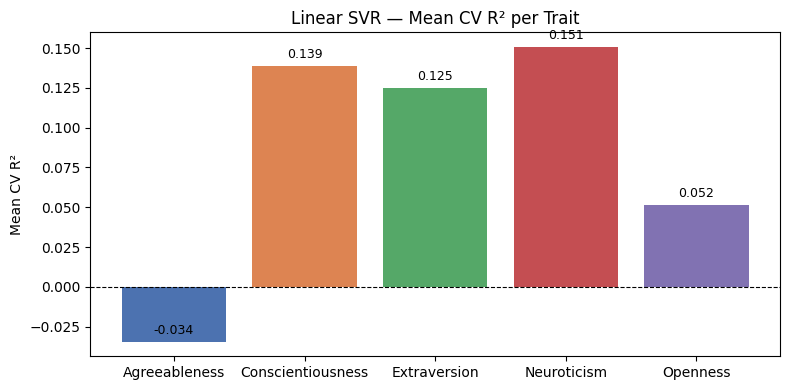

In [5]:
print("Linear SVR — 5-Fold Cross-Validation")
print("-" * 45)

_, summary_linear = cross_validate_model(
    linear_svr_model, X_all, y, big_five, n_splits=5
)

print(summary_linear[["MAE", "R2", "Pearson_r"]])
plot_cv_summary(summary_linear, "Linear SVR — Mean CV R² per Trait")

## 4. Non-Linear SVR (RBF Kernel)

### What is RBF SVR?
The **Radial Basis Function (RBF)** kernel maps data into an infinite-dimensional space, allowing SVR to capture **non-linear** relationships between words and personality scores.

### Why TruncatedSVD before RBF SVR?
RBF SVR requires computing distances between all pairs of samples — this is expensive with 100k TF-IDF features. **TruncatedSVD** (similar to PCA but works on sparse matrices) reduces the feature space to 300 dense dimensions first, making RBF computationally feasible.

### Key parameters
| Parameter | Role |
|---|---|
| `C` | Regularization strength |
| `gamma` | Controls how far the influence of a single training example reaches |
| `epsilon` | No-penalty tube width |

In [6]:
nonlinear_svr_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=3,
        max_features=200_000
    )),
    # Reduce to 300 dense dims so RBF kernel is feasible
    ("svd",  TruncatedSVD(n_components=300, random_state=42)),
    ("reg",  MultiOutputRegressor(
        SVR(kernel="rbf", C=1.0, gamma="scale", epsilon=0.1)
    ))
])

nonlinear_svr_model.fit(X_train, y_train)
pred_rbf = nonlinear_svr_model.predict(X_test)

mae_rbf = mean_absolute_error(y_test, pred_rbf, multioutput="raw_values")
r2_rbf  = [r2_score(y_test.iloc[:, i], pred_rbf[:, i]) for i in range(y.shape[1])]

print("Non-Linear SVR (RBF) — Test Set Performance")
print("MAE by trait:", dict(zip(big_five, mae_rbf.round(4))))
print("R²  by trait:", dict(zip(big_five, [round(r, 4) for r in r2_rbf])))

Non-Linear SVR (RBF) — Test Set Performance
MAE by trait: {'Extraversion': np.float64(0.589), 'Agreeableness': np.float64(0.3908), 'Conscientiousness': np.float64(0.5732), 'Neuroticism': np.float64(0.6961), 'Openness': np.float64(0.5076)}
R²  by trait: {'Extraversion': 0.1248, 'Agreeableness': -0.0152, 'Conscientiousness': 0.1196, 'Neuroticism': 0.0494, 'Openness': 0.0928}


Non-Linear SVR (RBF) — 5-Fold Cross-Validation
---------------------------------------------
                      MAE      R2  Pearson_r
Trait                                       
Agreeableness      0.4684 -0.1003     0.0609
Conscientiousness  0.5205  0.1428     0.4034
Extraversion       0.5679  0.1240     0.3707
Neuroticism        0.6614  0.0481     0.4208
Openness           0.4788  0.0428     0.2718


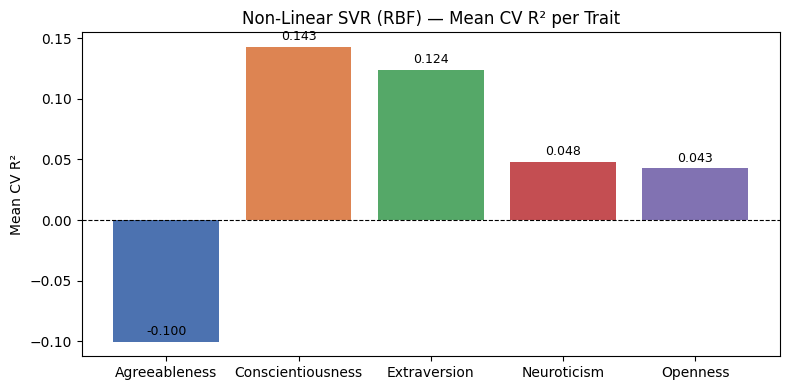

In [7]:
print("Non-Linear SVR (RBF) — 5-Fold Cross-Validation")
print("-" * 45)

_, summary_rbf = cross_validate_model(
    nonlinear_svr_model, X_all, y, big_five, n_splits=5
)

print(summary_rbf[["MAE", "R2", "Pearson_r"]])
plot_cv_summary(summary_rbf, "Non-Linear SVR (RBF) — Mean CV R² per Trait")

Model Comparison — Test Set
                   Linear SVR R²  RBF SVR R²  Linear SVR MAE  RBF SVR MAE  \
Extraversion              0.1006      0.1248          0.5983       0.5890   
Agreeableness            -0.0223     -0.0152          0.4001       0.3908   
Conscientiousness         0.0863      0.1196          0.5840       0.5732   
Neuroticism               0.1161      0.0494          0.6921       0.6961   
Openness                  0.0628      0.0928          0.5192       0.5076   

                   Linear Pearson r  RBF Pearson r  
Extraversion                 0.3272         0.3667  
Agreeableness                0.1072         0.1234  
Conscientiousness            0.2948         0.3531  
Neuroticism                  0.3672         0.3885  
Openness                     0.2600         0.3416  


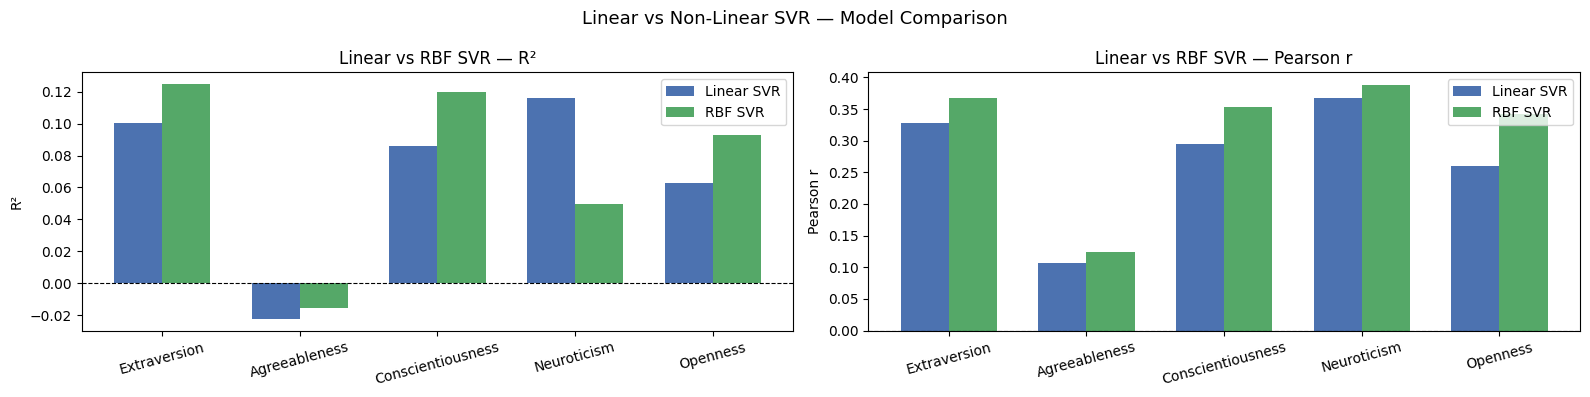

In [8]:
# Compute Pearson r for both models on test set
pearson_linear = [np.corrcoef(y_test.iloc[:, i], pred_linear[:, i])[0, 1] for i in range(len(big_five))]
pearson_rbf    = [np.corrcoef(y_test.iloc[:, i], pred_rbf[:, i])[0, 1]    for i in range(len(big_five))]

comparison = pd.DataFrame({
    "Linear SVR R²":    [round(r, 4) for r in r2_linear],
    "RBF SVR R²":       [round(r, 4) for r in r2_rbf],
    "Linear SVR MAE":   mae_linear.round(4),
    "RBF SVR MAE":      mae_rbf.round(4),
    "Linear Pearson r": [round(r, 4) for r in pearson_linear],
    "RBF Pearson r":    [round(r, 4) for r in pearson_rbf],
}, index=big_five)

print("Model Comparison — Test Set")
print(comparison)

# Plot side-by-side R²
x     = np.arange(len(big_five))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# R² comparison
axes[0].bar(x - width/2, comparison["Linear SVR R²"], width, label="Linear SVR", color="#4C72B0")
axes[0].bar(x + width/2, comparison["RBF SVR R²"],    width, label="RBF SVR",    color="#55A868")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xticks(x)
axes[0].set_xticklabels(big_five, rotation=15)
axes[0].set_ylabel("R²")
axes[0].set_title("Linear vs RBF SVR — R²")
axes[0].legend()

# Pearson r comparison
axes[1].bar(x - width/2, comparison["Linear Pearson r"], width, label="Linear SVR", color="#4C72B0")
axes[1].bar(x + width/2, comparison["RBF Pearson r"],    width, label="RBF SVR",    color="#55A868")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xticks(x)
axes[1].set_xticklabels(big_five, rotation=15)
axes[1].set_ylabel("Pearson r")
axes[1].set_title("Linear vs RBF SVR — Pearson r")
axes[1].legend()

plt.suptitle("Linear vs Non-Linear SVR — Model Comparison", fontsize=13)
plt.tight_layout()
plt.show()

## Results analysis

Support Vector Regression (SVR) was used to predict Big Five personality traits from narrative text. Two kernel versions were compared:

- **Linear SVR**: assumes approximately linear relationships between text features and personality
- **RBF SVR**: uses a nonlinear radial basis function kernel to capture more complex patterns

The models were evaluated using:

- **R²**: proportion of variance explained
- **MAE**: average prediction error
- **Pearson's r**: correlation between predicted and actual scores

SVR was one of the strongest model families tested. In particular, non-linear SVR performed best for all traits, 

- Extraversion (0.3272 vs. **0.3667**)
- Agreeableness (0.1072 vs. **0.1234**)
- Conscientiousness (0.2948 vs. **0.3531**)
- Neuroticism (0.3672 vs. **0.3885**)
- Openness (0.2600 vs. **0.3416**)

Though agreebleness was predicted somewhat higher with SVR, it remained the hardest trait to predict, consistent with earlier models. This suggest that narrative texts (at least in this dataset) did not capture agreeableness well, most likely due to its inclusion in prompts that were not intended to predict agreeableness. 

The overall findings suggest that support vector methods are highly effective for narrative-based personality prediction, and nonlinear kernels may provide additional benefit for several traits. This is most likely due to SVR’s ability to handle high-dimensional text features directly without requiring aggressive dimension reduction, allowing it to retain more information from the narratives and capture subtle patterns in language use that relate to personality differences.

# Trait-by-Trait Results

| Trait | Better Model | Key Result |
|---|---|---|
| Extraversion | RBF SVR | Best overall for Extraversion |
| Agreeableness | RBF SVR | Weak prediction for both models |
| Conscientiousness | RBF SVR | Stronger than linear version |
| Neuroticism | Linear SVR (R²) / RBF (r) | Mixed results |
| Openness | RBF SVR | Strongest model for Openness |

---

## Extraversion

| Metric | Linear SVR | RBF SVR |
|---|---:|---:|
| R² | 0.1006 | 0.1248 |
| MAE | 0.5983 | 0.5890 |
| Pearson r | 0.3272 | 0.3667 |

RBF SVR outperformed the linear version on all metrics, suggesting that Extraversion may be related to narrative language in a nonlinear way.

---

## Agreeableness

| Metric | Linear SVR | RBF SVR |
|---|---:|---:|
| R² | -0.0223 | -0.0152 |
| MAE | 0.4001 | 0.3908 |
| Pearson r | 0.1072 | 0.1234 |

Both models performed poorly. Agreeableness remained the hardest trait to predict, consistent with earlier models.

---

## Conscientiousness

| Metric | Linear SVR | RBF SVR |
|---|---:|---:|
| R² | 0.0863 | 0.1196 |
| MAE | 0.5840 | 0.5732 |
| Pearson r | 0.2948 | 0.3531 |

RBF SVR again performed better, showing strong predictive ability relative to other models.

---

## Neuroticism

| Metric | Linear SVR | RBF SVR |
|---|---:|---:|
| R² | 0.1161 | 0.0494 |
| MAE | 0.6921 | 0.6961 |
| Pearson r | 0.3672 | 0.3885 |

Results were mixed. Linear SVR had better R² and MAE, while RBF SVR had slightly higher correlation. Both models performed relatively well compared with other algorithms.

---

## Openness

| Metric | Linear SVR | RBF SVR |
|---|---:|---:|
| R² | 0.0628 | 0.0928 |
| MAE | 0.5192 | 0.5076 |
| Pearson r | 0.2600 | 0.3416 |

RBF SVR clearly outperformed Linear SVR, suggesting nonlinear language patterns are useful for predicting Openness.

---

# Overall Conclusion

